# Fase 5 · Texto, voz y cara de cada frase (Bloque 2)

**Objetivo:** situar cada frase de la transcripción oficial en el vídeo y unir, en la ventana de cada frase, lo que se dice (postura, bloque 2), cómo se dice (tono de voz, bloque 1) y cómo se ve (expresión facial, bloque 3). Con los tiempos, las citas del briefing y del chat saltan al segundo exacto del vídeo, y los momentos clave pueden salir también de la voz y de la cara.

In [1]:
# autoreload solo vigila nuestro código (src), no las librerías instaladas
%load_ext autoreload
%autoreload 1
%aimport src.config, src.text.alignment, src.text.alignment_eval, src.text.fusion

import json
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

from src.config import ROOT, EVENTS_DIR, HISTORY_DIR
from src.text.alignment import alinear, calidad, tokens, VELOCIDAD_MAXIMA
from src.text.alignment_eval import validar, periodista_en_pantalla, ritmo_anomalo

resultados_dir = ROOT / "benchmarks" / "results" / "fusion"
resultados_dir.mkdir(parents=True, exist_ok=True)
corpus = pd.read_parquet(HISTORY_DIR / "transcripts.parquet")
REFERENCIA = "2026-09-10"
frases_ref = corpus[corpus["date"] == REFERENCIA]

## 1. Diseño

- **Tiempo de cada frase.** La transcripción oficial no tiene tiempos; la del audio (`transcript.csv`, bloque 1) sí, pero contiene errores de reconocimiento y no coincide palabra por palabra con la oficial, que está editada. Las dos secuencias de palabras normalizadas se emparejan con el algoritmo de bloques comunes más largos (`difflib.SequenceMatcher`), que respeta el orden y tolera omisiones y sustituciones. Solo sirven de ancla los tramos de al menos tres palabras seguidas iguales: una coincidencia suelta de una o dos palabras ("good afternoon", "thank you") puede ser casual. Cada frase toma el tiempo de su primera y de su última palabra; las palabras sin pareja se interpolan entre sus vecinas. Se alinea la transcripción completa, preguntas incluidas, porque el audio también las contiene. Si el bloque 1 entrega segmentos en lugar de palabras, el tiempo de cada segmento se reparte entre sus palabras en proporción a su longitud.
- **Segmentos con duración imposible.** Whisper con marcas por segmento devuelve a veces segmentos que terminan antes de empezar o que encajan más palabras de las que se pueden decir en ese tiempo. Su inicio es fiable; su fin, no. Un segmento con más de 6 palabras por segundo (el habla normal ronda 2-3) alarga su fin hasta lo que tardaría al ritmo mediano de la rueda, sin pasar del inicio del siguiente. Ningún inicio se mueve.
- **Voz y cara por frase.** Media de cada señal en la ventana de la frase, ponderada por los segundos de solapamiento. La cara solo cuenta en los fotogramas con la presidenta en primer plano: durante las preguntas, la realización enfoca a los periodistas.
- **Desviación, no nivel.** Cada señal se expresa también como desviación respecto a la media del hablante en la rueda, en desviaciones típicas. En una banquera central el nivel dice poco, porque su expresión es casi siempre la misma; lo informativo es el cambio.
- **Momentos clave.** A los cuatro momentos de texto de la fase 6 se añaden hasta dos por cómo se dice: la frase relevante de la presidenta con la voz más activada y la de expresión facial más alejada de su media, si superan 1,5 desviaciones típicas. Solo compiten las frases de al menos 3 segundos: la media de una frase más corta sale de uno o dos fotogramas y ganaría por azar.
- **Resumen de la rueda.** `summary.json` recibe los tiempos de citas y momentos clave, la voz y la cara medias de la presidenta y su posición frente a las demás ruedas procesadas, cuando hay al menos tres. La etiqueta de la cara también es relativa: en la rueda de referencia ninguna emoción supera el 21 % de probabilidad media, así que la emoción con más probabilidad no describe nada.
- **Ejecución.** `scripts/fusion_eventos.py` lo hace para cada rueda con `transcript.csv`. Voz y cara son opcionales, y se puede volver a ejecutar sin duplicar nada; con `--sin-voz`, la fusión combina el texto solo con la cara.

## 2. Validación de la alineación con audio simulado

Antes de usar la transcripción real, el error de la alineación se mide en un caso con solución conocida. A partir de la transcripción oficial de la rueda de referencia se simula la salida de un reconocedor de voz: tiempos por palabra a unas 2,4 palabras por segundo, palabras omitidas y mal reconocidas, muletillas y segmentos de 8 a 20 palabras, como los de Whisper. Se prueban cuatro niveles de error, con cinco simulaciones cada uno.

**Requisito.** El uso principal de los tiempos es saltar al inicio de una frase desde una cita o un momento clave, y un desfase de 1 a 2 segundos apenas se percibe. Se exige un error mediano inferior a 1 s y un percentil 95 inferior a 3 s con un 15 % de palabras mal reconocidas.

In [2]:
validacion = validar(frases_ref, niveles=[0.0, 0.08, 0.15, 0.25])
validacion.to_csv(resultados_dir / "validacion_alineacion.csv", index=False)
validacion

,error_palabras,mediana_s,p95_s,max_s,menos_de_1s,cobertura_media
0,0.00,0.22,1.03,3.30,0.945,0.998
1,0.08,0.28,1.16,3.39,0.932,0.893
2,0.15,0.29,1.29,3.85,0.919,0.795
3,0.25,0.34,1.29,15.42,0.892,0.631


## 3. Transcripción del audio: comprobación

Antes de combinar, se comprueba que `transcript.csv` (bloque 1) cubra el mismo vídeo que `face.csv` (bloque 3), de modo que texto y cara compartan reloj, y cuántos segmentos tienen una duración imposible.

In [3]:
carpeta_ref = EVENTS_DIR / REFERENCIA
transcripcion = pd.read_csv(carpeta_ref / "transcript.csv")
cara = pd.read_csv(carpeta_ref / "face.csv")

con_texto = transcripcion[transcripcion["text"].notna()]
palabras = con_texto["text"].map(lambda t: len(tokens(t)))
duracion = con_texto["end"] - con_texto["start"]
imposibles = ((duracion <= 0) | (palabras > VELOCIDAD_MAXIMA * duracion)).sum()
print(f"transcript.csv: {len(transcripcion)} segmentos, de {transcripcion['start'].min():.0f} a {transcripcion['end'].max():.0f} s "
      f"(face.csv cubre {cara['end'].max():.0f} s de vídeo)")
print(f"  sin texto: {transcripcion['text'].isna().sum()} | con duración imposible: {imposibles} de {len(con_texto)} ({imposibles / len(con_texto):.0%})")

transcript.csv: 541 segmentos, de 0 a 3051 s (face.csv cubre 3052 s de vídeo)
  sin texto: 27 | con duración imposible: 45 de 514 (9%)


**Resultado.** `transcript.csv` cubre el mismo vídeo que `face.csv`, de modo que texto y cara comparten reloj. El 9 % de los segmentos con texto tiene una duración imposible y se corrige como se describe en el diseño. Las etiquetas de hablante y de sección de la transcripción del audio no se usan: la fusión toma las de la transcripción oficial.

## 4. Tiempo de cada frase en la rueda de referencia

`scripts/fusion_eventos.py --sin-voz` se aplica a las seis ruedas de 2026, todas con `transcript.csv`: esta versión de la fusión combina el texto con la expresión facial en las ruedas con `face.csv`. Para cada rueda informa de la proporción de frases del panel con al menos la mitad de sus palabras encontradas en el audio, de si el orden temporal es correcto y, si hay `face.csv`, de qué proporción de frases tiene expresión facial.

In [4]:
salida = subprocess.run([sys.executable, "scripts/fusion_eventos.py", "--sin-voz"], cwd=ROOT, capture_output=True, text=True)
print(salida.stdout or salida.stderr)

[2026-02-05] frases del panel con al menos la mitad de sus palabras en el audio: 100% | orden temporal correcto: True | momentos clave: 4
[2026-03-19] frases del panel con al menos la mitad de sus palabras en el audio: 100% | orden temporal correcto: True | momentos clave: 4
[2026-04-30] frases del panel con al menos la mitad de sus palabras en el audio: 100% | orden temporal correcto: True | momentos clave: 4
[2026-06-11] frases del panel con al menos la mitad de sus palabras en el audio: 100% | orden temporal correcto: True | momentos clave: 4
[2026-07-23] frases del panel con al menos la mitad de sus palabras en el audio: 99% | orden temporal correcto: True | momentos clave: 4
[2026-09-10] frases del panel con al menos la mitad de sus palabras en el audio: 100% | orden temporal correcto: True | con cara: 97% | momentos clave: 5



### 4.1 Comprobación independiente con la cara y efecto de las dos reglas de la alineación

La cara ofrece una comprobación que no depende ni del texto ni del audio: durante las preguntas, la realización enfoca a los periodistas (`person = "otro"` en `face.csv`) y, durante la declaración y las respuestas, a la presidenta. Si los tiempos son correctos, la proporción de primeros planos de otra persona debe ser alta en las preguntas y casi nula en el resto.

La tabla compara tres variantes de la alineación: con anclas de una sola palabra, con anclas de tres palabras y con anclas de tres palabras y los fines corregidos (la elegida). `frases_ritmo_imposible` cuenta las frases de ocho palabras o más con menos de 0,2 o más de 1,2 segundos por palabra.

In [5]:
variantes = []
for nombre, opciones in [("Anclas de 1 palabra", dict(min_bloque=1, corregir_fines=False)),
                         ("Anclas de 3 palabras", dict(min_bloque=3, corregir_fines=False)),
                         ("Anclas de 3 palabras y fines corregidos", dict(min_bloque=3, corregir_fines=True))]:
    tiempos = alinear(frases_ref, transcripcion, **opciones)
    periodista = periodista_en_pantalla(tiempos, frases_ref, cara)
    variantes.append({"variante": nombre, **calidad(tiempos),
                      "inicio_primera_frase_s": round(tiempos["start"].iloc[0], 1),
                      "frases_ritmo_imposible": ritmo_anomalo(tiempos, frases_ref),
                      "periodista_en_declaracion": round(periodista["statement"], 3),
                      "periodista_en_respuestas": round(periodista["answer"], 3),
                      "periodista_en_preguntas": round(periodista["question"], 3)})
variantes = pd.DataFrame(variantes).round(3)
variantes.to_csv(resultados_dir / "variantes_alineacion.csv", index=False)
variantes

,variante,frases,cobertura_media,frases_cobertura_50,orden_correcto,inicio_primera_frase_s,frases_ritmo_imposible,periodista_en_declaracion,periodista_en_respuestas,periodista_en_preguntas
0,Anclas de 1 palabra,308,0.97,0.994,True,0.0,23,0.01,0.054,0.975
1,Anclas de 3 palabras,308,0.96,0.994,True,90.4,22,0.00,0.048,0.964
2,Anclas de 3 palabras y fines corregidos,308,0.96,0.994,True,90.4,8,0.00,0.048,0.964


In [6]:
# Dónde empiezan las preguntas según el texto alineado y según la realización
postura = pd.read_csv(carpeta_ref / "stance.csv")
tiempos = alinear(frases_ref, transcripcion)
primera_pregunta = tiempos.merge(frases_ref[["sentence_id", "role"]], on="sentence_id").query("role == 'question'")["start"].min()
otro = cara[cara["face_detected"].astype(bool) & (cara["person"] == "otro")].copy()
otro["tramo"] = (otro["start"].diff() != 1).cumsum()
tramos = otro.groupby("tramo").agg(inicio=("start", "min"), segundos=("start", "size"))
primer_periodista = tramos[(tramos["inicio"] > 120) & (tramos["segundos"] >= 3)]["inicio"].min()
print(f"Primera pregunta según la alineación: {primera_pregunta:.0f} s · primer plano de otra persona tras la apertura: {primer_periodista:.0f} s")
print(f"Frases del panel con tiempo: {postura['start'].notna().sum()} de {len(postura)}")

Primera pregunta según la alineación: 1087 s · primer plano de otra persona tras la apertura: 1080 s
Frases del panel con tiempo: 253 de 253


## 5. Señales de la rueda de referencia

Postura de cada frase y expresión facial de la presidenta a lo largo de la rueda; las líneas de puntos marcan los momentos clave. La línea de la cara se corta durante las preguntas de los periodistas, que no forman parte del panel.

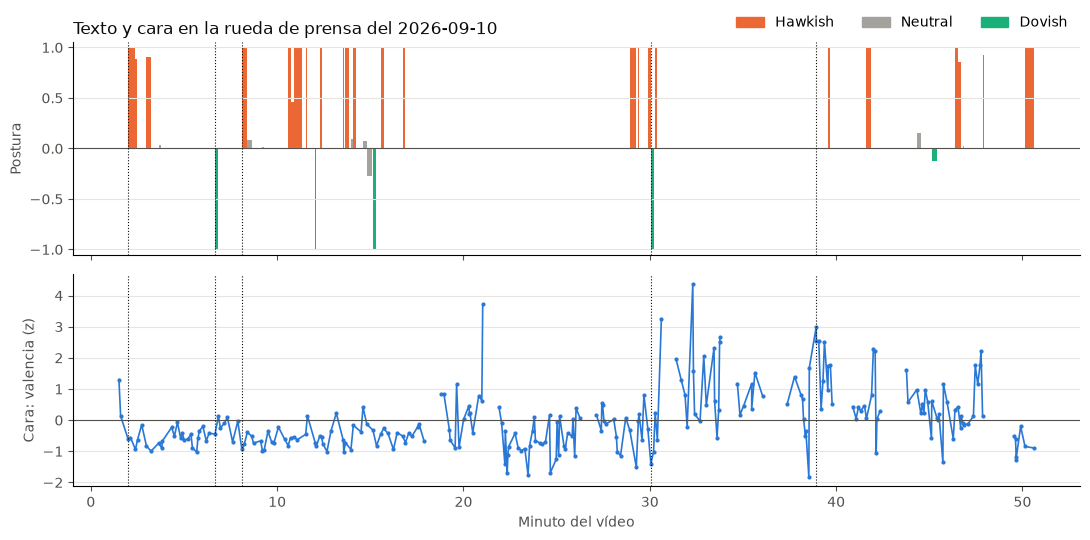

[  2.0 min] Hawkish signal in the statement: The Governing Council today decided to raise the three key ECB interest rates by 25 basis points.
[  6.7 min] Dovish signal in the statement: Over the medium term, consumption should be supported by gradually falling energy prices and a strong labour market.
[  8.1 min] Hawkish signal in the statement: Inflation increased to 3.3 per cent in August, from 2.9 per cent in July.
[ 30.1 min] Dovish signal in the Q&A: And we've also been surprised on the inflation front, because we have seen inflation, in a way, lower than we had anticipated.
[ 38.9 min] Facial expression shift: valence +2.5 SD from her average in this press conference: You can argue ad infinitum about minuscule moves in one direction or the other.

Citas del informe: [(5, 150.4), (10, 229.4), (58, 760.3), (61, 812.9)]
Cara: {'valence_mean': -0.122, 'arousal_mean': 0.111, 'label': None, 'frames': 2439, 'valence_z_vs_history': None}


In [7]:
senales = pd.read_csv(carpeta_ref / "signals.csv")
resumen = json.loads((carpeta_ref / "summary.json").read_text(encoding="utf-8"))
# Paleta del proyecto: naranja = hawkish (como las subidas), aguamarina = dovish (como las bajadas)
NARANJA, AGUAMARINA, GRIS, AZUL = "#eb6834", "#1baf7a", "#a3a29d", "#2a78d6"
TINTA, TINTA_SECUNDARIA, REJILLA = "#0b0b0b", "#52514e", "#e6e5e0"

minutos = senales["start"] / 60
fig, ejes = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
ejes[0].bar(minutos, senales["score"], width=(senales["end"] - senales["start"]) / 60, align="edge",
            color=senales["label"].map({"hawkish": NARANJA, "dovish": AGUAMARINA, "neutral": GRIS}))
ejes[0].set_ylim(-1.05, 1.05)
ejes[0].set_ylabel("Postura", color=TINTA_SECUNDARIA)
ejes[0].legend(handles=[Patch(color=NARANJA, label="Hawkish"), Patch(color=GRIS, label="Neutral"),
                        Patch(color=AGUAMARINA, label="Dovish")], frameon=False, ncol=3,
               loc="lower right", bbox_to_anchor=(1, 1))
# Un trazo por tramo de frases seguidas: la línea se corta en las preguntas (más de 30 s sin frases del panel)
tramo = (senales["start"] - senales["end"].shift() > 30).cumsum()
for _, grupo in senales.groupby(tramo):
    ejes[1].plot(grupo["start"] / 60, grupo["face_valence_z"], color=AZUL, linewidth=1.2, marker="o", markersize=2)
ejes[1].set_ylabel("Cara: valencia (z)", color=TINTA_SECUNDARIA)
for eje in ejes:
    eje.axhline(0, color=TINTA_SECUNDARIA, linewidth=0.8)
    eje.grid(axis="y", color=REJILLA, linewidth=0.8)
    eje.spines[["top", "right"]].set_visible(False)
    eje.tick_params(colors=TINTA_SECUNDARIA)
    for momento in resumen["key_moments"]:
        if momento["start"] is not None:
            eje.axvline(momento["start"] / 60, color=TINTA, linestyle=":", linewidth=0.8)
ejes[1].set_xlabel("Minuto del vídeo", color=TINTA_SECUNDARIA)
ejes[0].set_title(f"Texto y cara en la rueda de prensa del {REFERENCIA}", loc="left", color=TINTA)
fig.tight_layout()
fig.savefig(resultados_dir / f"senales_{REFERENCIA}.png", dpi=150)
plt.show()

for momento in resumen["key_moments"]:
    print(f"[{momento['start'] / 60:5.1f} min] {momento['reason']}: {momento['text']}")
print("\nCitas del informe:", [(c["sentence_id"], c["start"]) for c in resumen["citations"]])
print("Cara:", resumen["face"])

**Lectura.** La valencia facial es más baja y estable durante la declaración (minutos 1,5 a 18), que la presidenta lee, y más variable en las respuestas. Los dos picos más altos, en el minuto 21 («And there is nothing to report») y en el 32 («That's number one», de 1,4 s), no compiten como momento clave: el modelo de postura clasifica las dos frases como ajenas a la política monetaria (`relevant = False`).

## 6. Decisión

**La alineación con la transcripción real cumple el requisito y se adopta, con dos reglas añadidas a la vista de los datos reales. Esta versión de la fusión combina el texto con la expresión facial.**

- **Validación simulada (sección 2).** Con un 15 % de palabras mal reconocidas, el error mediano al situar el inicio de una frase es 0,29 s y el percentil 95, 1,29 s, dentro del requisito (1 s y 3 s). Las dos reglas añadidas apenas cambian este resultado (antes, 0,28 s y 1,31 s).
- **Datos reales (sección 4).** En las seis ruedas de 2026, 1.230 de las 1.231 frases del panel reciben tiempo, el orden temporal es correcto en todas y la cobertura media va de 0,96 a 0,98. En la rueda de referencia, las 253 frases del panel reciben tiempo y el 99,4 % de las 308 frases de la transcripción, preguntas incluidas, tiene al menos la mitad de sus palabras emparejadas con el audio (cobertura media 0,96).
- **Comprobación independiente con la cara (sección 4.1).** En las frases que la alineación sitúa como preguntas, el 96 % de los primeros planos es de otra persona (los periodistas), frente al 5 % en las respuestas y el 0 % en la declaración. La primera pregunta cae en el segundo 1.087 y la realización enfoca por primera vez a un periodista en el 1.080. Dos fuentes independientes, el texto alineado con el audio y la imagen, coinciden.
- **Reglas añadidas por lo que mostraron los datos reales:**
  1. *Anclas de al menos tres palabras.* Con anclas de una palabra, el "good afternoon" del gobernador anfitrión, que abre el vídeo, llevaba al segundo 0 el inicio de la primera frase de la presidenta, que empieza en el 90.
  2. *Fines de segmento corregidos.* El 9 % de los segmentos de Whisper (45 de 514) tiene una duración imposible, como 23 palabras en 1,5 s. Alargar su fin hasta el ritmo mediano reduce de 22 a 8 las frases con un ritmo imposible, sin mover ningún inicio y sin cambiar la comprobación con la cara. Una primera versión que además retrasaba los inicios solapados acumulaba desfases de hasta 29 s en las respuestas y se descartó.
- **Cara.** El 97 % de las frases del panel tiene expresión facial. La valencia es más baja al leer la declaración (−0,20) que al responder (−0,08), en parte por mirar el papel, de modo que, con la desviación sobre toda la rueda, los momentos de cara tienden a salir de las respuestas. Calcularla dentro de cada parte no lo resuelve: en la declaración la variación es mínima (desviación típica 0,06) y levantar la vista del papel pasaría por un cambio de expresión. Se mantiene la desviación sobre toda la rueda y solo compiten las frases de al menos 3 s: el momento de cara elegido es una respuesta sobre la propuesta de cancelar deuda («You can argue ad infinitum about minuscule moves…», +2,5 desviaciones típicas) en lugar de una frase de 1,8 s con +3,3 sostenida por dos fotogramas.
- **Resultado en la aplicación.** En las seis ruedas, las citas del informe y los momentos clave tienen su segundo del vídeo y la postura entra en la línea temporal. En la de referencia, además, la cabecera muestra la valencia facial media (−0,12). La etiqueta relativa de la cara («más tensa de lo habitual»…) se activa cuando hay al menos tres ruedas más procesadas con cara.